# 02. Density-Based Learning: DBSCAN and HDBSCAN
**Algorithms implemented:** DBSCAN and HDBSCAN (hierarchical density-based clustering).

**Dataset:** real USGS earthquake catalogue for 2023 (global epicenters with magnitude >= 4.5; `data/earthquakes.csv`).
Density-based clustering is the natural tool for this data: seismic zones appear as dense chains of epicenters,
while isolated intraplate events are noise. Distances use the **haversine** (great-circle) metric because
latitude/longitude degrees are not a Euclidean space.

In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Density-based clustering algorithms ----
from sklearn.cluster import DBSCAN, HDBSCAN
# ---- Nearest-neighbor search (used to pick epsilon) ----
from sklearn.neighbors import NearestNeighbors
# ---- Evaluation metrics ----
from sklearn.metrics import silhouette_score

# Aesthetics setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print("Density-based libraries loaded successfully!")


Density-based libraries loaded successfully!


In [2]:
# ---- Load the real USGS earthquake catalogue (global, 2023) ----
df = pd.read_csv('../data/earthquakes.csv')
print(f"Full catalogue (magnitude >= 4.0): {len(df):,} events")
print(df.head(3).to_string(index=False))

# Keep well-recorded moderate+ events: magnitude >= 4.5
quakes = df[df['mag'] >= 4.5].reset_index(drop=True)
print(f"\nAnalysed subset (magnitude >= 4.5): {len(quakes):,} events")

# ---- Convert epicenters to radians [latitude, longitude] ----
# scikit-learn's 'haversine' metric expects radian coordinates and computes
# great-circle distance on the sphere (correct for global data).
X_rad = np.radians(quakes[['latitude', 'longitude']].values)
print("Coordinate range (deg): lat", quakes.latitude.min(), "to", quakes.latitude.max(),
      "| lon", quakes.longitude.min(), "to", quakes.longitude.max())


Full catalogue (magnitude >= 4.0): 16,190 events
                    time  latitude  longitude  depth  mag                         place
2023-12-30T23:55:48.472Z   44.6077   148.9343 35.000  4.4 108 km SE of Kuril’sk, Russia
2023-12-30T23:34:10.971Z   -3.6423  -102.9478 10.000  4.6     central East Pacific Rise
2023-12-30T22:39:19.128Z   40.0474   142.1067 48.231  4.3      25 km ESE of Noda, Japan

Analysed subset (magnitude >= 4.5): 7,638 events
Coordinate range (deg): lat -65.8497 to 86.2658 | lon -179.9897 to 179.9961


## 1. DBSCAN

### Step-by-Step Algorithm (DBSCAN)
1. **Parameters:** radius ε and minimum points MinPts (here ε = 0.03 rad ~ 191 km, MinPts = 10).
2. For every event count its ε-neighborhood (haversine distance); events with >= MinPts neighbors are **core points**.
3. **Grow clusters:** connect core points within ε of each other (density-reachability chains).
4. Attach border events (within ε of a core point) to that core's cluster.
5. Every event that is neither core nor border becomes **noise (-1)** - here: isolated earthquakes.
6. **Output:** arbitrary-shaped clusters + explicit noise labels; no K required.

### How ε Is Chosen Here
1. Convert epicenters to radians and take the distance to each event's 10th nearest neighbor (haversine).
2. Sort those distances and plot the k-distance graph; the "knee" marks the transition from dense
   seismic zones to sparse isolated events (~0.03 rad).
3. Fit DBSCAN and check the clusters against known seismic regions (Philippines, Japan, Tonga, ...).

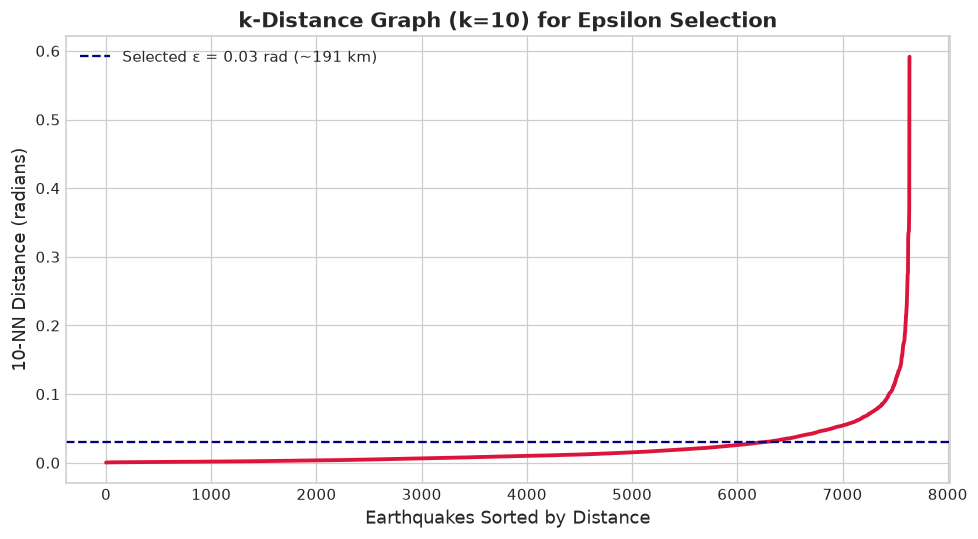

In [3]:
# ---- Choosing epsilon from the k-distance graph (haversine metric) ----
# Sorted distance to each event's k-th nearest neighbor. The knee marks the
# transition from dense seismic zones to sparse, isolated events.
min_samples = 10
nbrs = NearestNeighbors(n_neighbors=min_samples, metric='haversine').fit(X_rad)
distances, _ = nbrs.kneighbors(X_rad)
k_distances = np.sort(distances[:, -1])   # radians (0.03 rad = 191 km on Earth)

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='crimson', linewidth=2.5)
plt.title(f"k-Distance Graph (k={min_samples}) for Epsilon Selection", fontsize=14, fontweight='bold')
plt.xlabel("Earthquakes Sorted by Distance", fontsize=12)
plt.ylabel(f"{min_samples}-NN Distance (radians)", fontsize=12)
plt.axhline(y=0.03, color='navy', linestyle='--', label='Selected ε = 0.03 rad (~191 km)')
plt.legend()
plt.tight_layout()
plt.show()


DBSCAN: 55 clusters, 1,029 noise events (13.5%)


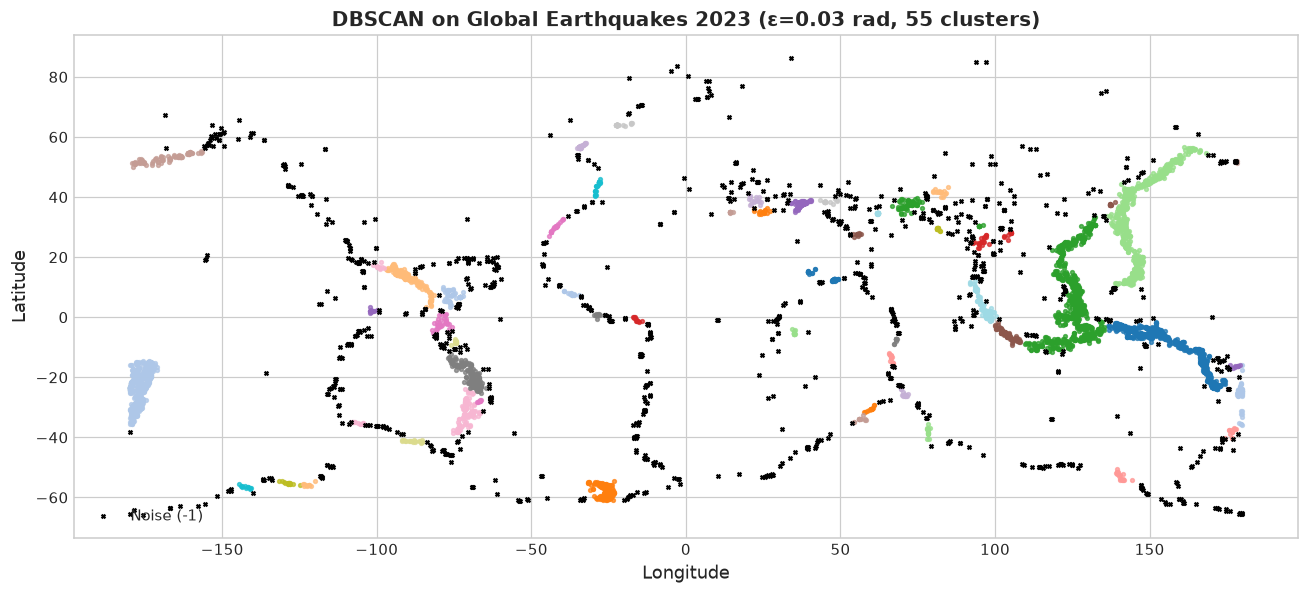

In [4]:
# ---- Fit DBSCAN with the chosen epsilon and MinPts ----
# DBSCAN grows clusters from core events, connects them via density-reachability,
# and labels everything else as noise (-1).
eps_selected = 0.03   # radians -> 0.03 * 6371 km ~ 191 km
dbscan = DBSCAN(eps=eps_selected, min_samples=min_samples, metric='haversine')
db_labels = dbscan.fit_predict(X_rad)

# Identify which events are core points (returned by the model) vs. border points
core_samples_mask = np.zeros_like(db_labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = np.sum(db_labels == -1)
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise_db:,} noise events ({n_noise_db / len(X_rad) * 100:.1f}%)")

# ---- Visualize epicenters: clustered events in color, noise as black crosses ----
plt.figure(figsize=(12, 5.5))
palette = sns.color_palette("tab20", max(n_clusters_db, 1))
for k in range(n_clusters_db):
    mask = db_labels == k
    plt.scatter(quakes.longitude[mask], quakes.latitude[mask], s=6, color=palette[k % 20], alpha=0.75)

noise_mask = db_labels == -1
plt.scatter(quakes.longitude[noise_mask], quakes.latitude[noise_mask], s=6, color='black', marker='x', label='Noise (-1)')
plt.title(f"DBSCAN on Global Earthquakes 2023 (ε={eps_selected} rad, {n_clusters_db} clusters)", fontsize=13, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


In [5]:
# ---- Real-world sanity check: which region does each large cluster cover? ----
def region_name(place):
    """Extract the country/region part from a USGS place string."""
    return place.split(",")[-1].strip() if "," in place else place

largest_clusters = pd.Series(db_labels[db_labels != -1]).value_counts().head(6)
print("Largest DBSCAN clusters and their dominant region:")
for cluster_id, size in largest_clusters.items():
    mask = db_labels == cluster_id
    region = quakes.loc[mask, 'place'].map(region_name).mode()[0]
    print(f" - Cluster {cluster_id:2d}: {size:4d} events | center "
          f"{quakes.latitude[mask].mean():6.1f}, {quakes.longitude[mask].mean():7.1f} | {region}")


Largest DBSCAN clusters and their dominant region:
 - Cluster  4: 1629 events | center    6.1,   126.1 | Philippines
 - Cluster  0: 1068 events | center  -12.5,   160.0 | Papua New Guinea
 - Cluster  1:  947 events | center  -24.0,  -154.5 | Tonga
 - Cluster  5:  895 events | center   30.8,   145.0 | Japan region
 - Cluster  2:  253 events | center  -57.8,   -26.3 | South Sandwich Islands region
 - Cluster  8:  207 events | center   37.7,    37.2 | Turkey


## 2. HDBSCAN

### Step-by-Step Algorithm (HDBSCAN)
1. Compute the **core distance** d_core(p) = distance (haversine) from p to its k-th nearest neighbor.
2. Define the **mutual reachability distance**: d_mreach(a,b) = max{d_core(a), d_core(b), d(a,b)}.
3. Build a **minimum spanning tree** on the mutual-reachability graph.
4. Convert the MST into a **cluster hierarchy** and then into a **condensed tree** (cluster births/deaths).
5. Score candidate clusters by **stability** S(C) = Σ (λ_p − λ_birth(C)) and keep the most stable ones.
6. **Output:** clusters of varying density, membership probabilities, and noise labels - with no global ε.

HDBSCAN: 40 clusters, 1,643 noise events (21.5%)


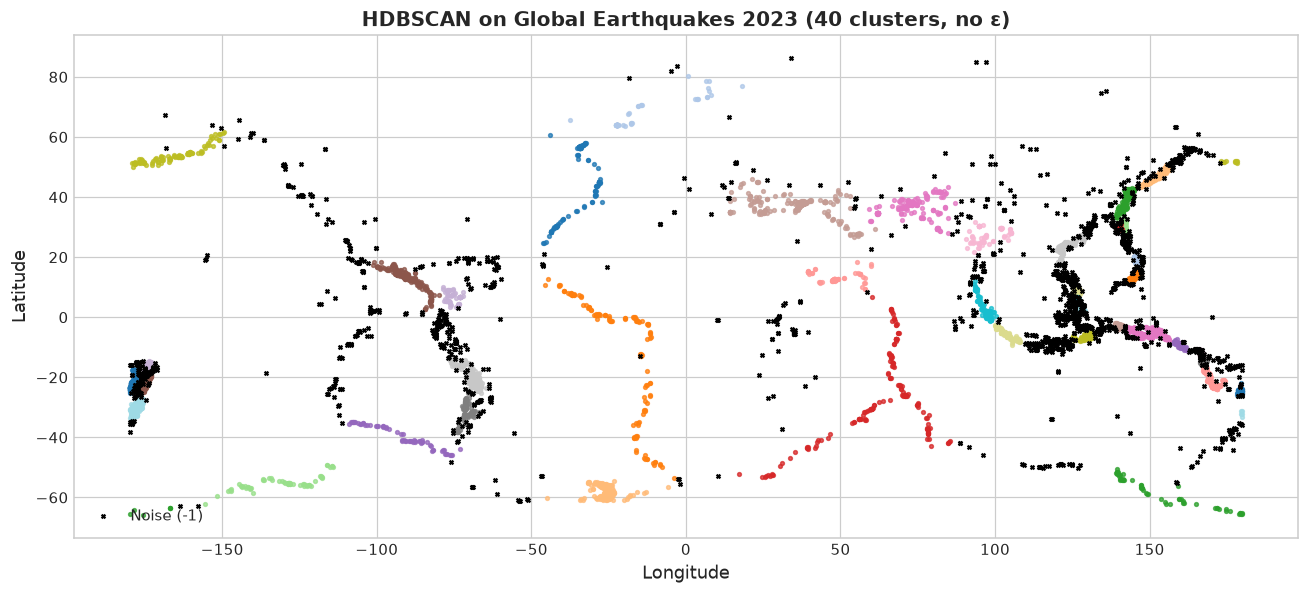

In [6]:
# ---- Fit HDBSCAN (no global epsilon required) ----
# min_cluster_size = smallest group considered a cluster; min_samples controls conservativeness.
hdb = HDBSCAN(min_cluster_size=50, min_samples=10, metric='haversine', copy=False)
hdb_labels = hdb.fit_predict(X_rad)

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise_hdb = np.sum(hdb_labels == -1)
print(f"HDBSCAN: {n_clusters_hdb} clusters, {n_noise_hdb:,} noise events ({n_noise_hdb / len(X_rad) * 100:.1f}%)")

# ---- Visualize the HDBSCAN partition ----
plt.figure(figsize=(12, 5.5))
palette = sns.color_palette("tab20", max(n_clusters_hdb, 1))
for k in range(n_clusters_hdb):
    mask = hdb_labels == k
    plt.scatter(quakes.longitude[mask], quakes.latitude[mask], s=6, color=palette[k % 20], alpha=0.75)

noise_mask = hdb_labels == -1
plt.scatter(quakes.longitude[noise_mask], quakes.latitude[noise_mask], s=6, color='black', marker='x', label='Noise (-1)')
plt.title(f"HDBSCAN on Global Earthquakes 2023 ({n_clusters_hdb} clusters, no ε)", fontsize=13, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


## 3. Summary
Both algorithms recover the global seismic structure: dense chains of epicenters along tectonic plate
boundaries (the Ring of Fire) become clusters, while isolated events are flagged as noise. Since the
catalogue has no ground-truth labels, quality is judged with cluster count, noise share, silhouette on
non-noise events, and the real-world region check above.

In [7]:
# ---- Summary metrics (silhouette computed on a fixed 3,000-event sample) ----
# Full pairwise distances on 7,638 events would be O(n^2); a random sample keeps it fast.
sample_idx = np.random.RandomState(42).choice(len(X_rad), size=3000, replace=False)

def density_metrics(name, labels):
    """Compute clustering summary metrics for one partition."""
    sample_labels = labels[sample_idx]
    keep = sample_labels != -1                      # silhouette only on clustered events
    sil = silhouette_score(X_rad[sample_idx[keep]], sample_labels[keep], metric='haversine')
    largest = pd.Series(labels[labels != -1]).value_counts().iloc[0]
    return {
        "Algorithm": name,
        "Clusters Found": len(set(labels)) - (1 if -1 in labels else 0),
        "Noise Events (%)": f"{(labels == -1).mean() * 100:.1f}%",
        "Largest Cluster": largest,
        "Silhouette (3k sample)": sil,
    }

comparison_table = pd.DataFrame([
    density_metrics("DBSCAN", db_labels),
    density_metrics("HDBSCAN", hdb_labels),
]).set_index("Algorithm")

display(comparison_table.style.highlight_max(subset=['Largest Cluster', 'Silhouette (3k sample)'], color='lightgreen'))


,Clusters Found,Noise Events (%),Largest Cluster,Silhouette (3k sample)
Algorithm,,,,
DBSCAN,55,13.5%,1629,0.326009
HDBSCAN,40,21.5%,560,0.630652
